In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
from typing import TypedDict, Literal, Annotated
from pydantic import BaseModel, Field
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
import operator

In [2]:
generator_model = ChatOllama(model="llama3.2:latest")
evaluation_model = ChatOllama(model="llama3.2:latest")
optimization_model = ChatOllama(model="llama3.2:latest")

In [3]:
#state
class TweetState(TypedDict):
    topic: str
    tweet: str
    evaluation: Literal['Approved', 'Needs Improvement']
    feedback: str
    iteration: int
    max_iteration: int
    
    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]
    

In [4]:

class TweetEvaluation(BaseModel):
    evaluation: Literal['Approved', 'Needs Improvement'] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")

In [5]:
structured_evaluation_model = evaluation_model.with_structured_output(TweetEvaluation)

In [6]:
def generate_tweet(state: TweetState):

    # prompt
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]

    # send generator_llm
    response = generator_model.invoke(messages).content

    # return response
    return {'tweet': response, 'tweet_history': [response]}

In [7]:
def evaluate_tweet(state: TweetState):

    # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "Approved" or "Needs Improvement"  
- feedback: One paragraph
""")
]

    response = structured_evaluation_model.invoke(messages)

    return {'evaluation':response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

In [8]:
def optimize_tweet(state: TweetState):

    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = optimization_model.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

In [9]:
def route_evaluation(state: TweetState):
    if state['evaluation'] == 'Approved' or state['iteration'] >= state['max_iteration']:
        return 'Approved'
    else:
        return 'Needs Improvement'

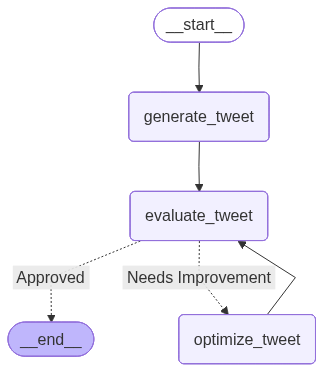

In [10]:
graph=StateGraph(TweetState)

graph.add_node('generate_tweet',generate_tweet)
graph.add_node('evaluate_tweet',evaluate_tweet)
graph.add_node('optimize_tweet',optimize_tweet)

graph.add_edge(START,'generate_tweet')
graph.add_edge('generate_tweet','evaluate_tweet')
graph.add_conditional_edges('evaluate_tweet', route_evaluation, {'Approved':END, 'Needs Improvement':'optimize_tweet'})
graph.add_edge('optimize_tweet','evaluate_tweet')

graph.compile()  


In [13]:
workflow=graph.compile()

initial_state = {
    "topic": "Office meetings",
    "iteration": 1,
    "max_iteration": 3
}
result = workflow.invoke(initial_state)


In [14]:
result

{'topic': 'Office meetings',
 'tweet': '"Office meeting: where \'synergy\' is just a fancy word for \'we\'re all bored and need snacks\'" #officeprobs #meetingsarethebest',
 'evaluation': 'Approved',
 'feedback': "This tweet effectively uses a relatable office setting to poke fun at corporate jargon. The punchline 'we're all bored and need snacks' is concise, funny, and unexpected, making it likely to elicit a chuckle. The use of hashtags adds to the tweet's visibility and relatability. However, the tweet could be slightly improved by using more creative language or a punchier opening line to make the humor even more surprising.",
 'iteration': 1,
 'max_iteration': 3,
 'tweet_history': ['"Office meeting: where \'synergy\' is just a fancy word for \'we\'re all bored and need snacks\'" #officeprobs #meetingsarethebest'],
 'feedback_history': ["This tweet effectively uses a relatable office setting to poke fun at corporate jargon. The punchline 'we're all bored and need snacks' is concise